# 🌿 Model 1 — Target EC & Saran Rasio A/B Mix (Cloud)

**Input :** `n, p, k, ec_aktual, ph_tanah, kelembapan_udara, suhu, fase`  
**Output :** `target_ec` → dari situ diturunkan `volume_a_ml` dan `volume_b_ml` per 10 L air

Model ini jalan di cloud (Flask/FastAPI), ukuran file tidak dibatasi.

### Logika A/B Mix
| | Mix A | Mix B |
|---|---|---|
| **Isi utama** | Ca(NO₃)₂, KNO₃, Fe-EDTA | KH₂PO₄, K₂SO₄, MgSO₄ |
| **Fungsi** | Sumber N & Ca | Sumber P, K, Mg |

Rasio disesuaikan fase:
- **Vegetatif** → A sedikit lebih banyak (N dominan)
- **Generatif** → B sedikit lebih banyak (K & P dominan)

## Cell 1 — Import Library

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('✅ Library siap')

✅ Library siap


## Cell 2 — Generate / Load Dataset

In [2]:
# ── Coba load dari CSV dulu, kalau tidak ada generate baru ──
try:
    df = pd.read_csv('dataset_paprika_adaptif.csv')
    print(f'✅ Dataset loaded: {df.shape}')
except FileNotFoundError:
    print('⚠️  CSV tidak ditemukan, generate dataset sintetis...')

    n_samples = 2000
    fase = np.random.choice([0, 1], n_samples, p=[0.55, 0.45])
    is_veg = (fase == 0)

    suhu = np.where(is_veg,
        np.random.normal(26.5, 2.0, n_samples),
        np.random.normal(28.5, 2.2, n_samples)).clip(20, 35)

    kelembapan_udara = np.clip(
        85 - 0.9*(suhu-25) + np.random.normal(0, 5, n_samples), 40, 95)

    es = 0.6108 * np.exp((17.27*suhu)/(suhu+237.3))
    vpd = (es - es*(kelembapan_udara/100)).round(4)

    n_ppm = np.where(is_veg,
        np.random.uniform(180,250,n_samples),
        np.random.uniform(120,180,n_samples)).round(2)
    p_ppm = np.where(is_veg,
        np.random.uniform(40,65,n_samples),
        np.random.uniform(50,80,n_samples)).round(2)
    k_ppm = np.where(is_veg,
        np.random.uniform(150,210,n_samples),
        np.random.uniform(220,300,n_samples)).round(2)

    base_ec = np.where(is_veg, 1.6, 2.0)
    ec_aktual = np.clip(base_ec + np.random.normal(0,0.12,n_samples), 0.8, 3.5).round(3)
    ph_tanah = np.where(is_veg,
        np.random.normal(6.0,0.25,n_samples),
        np.random.normal(6.3,0.25,n_samples)).clip(5.5,7.5).round(3)

    def label_target_ec(n, p, k, ec, rh, tanah, suhu_, ph, fase_, vpd_):
        target = np.where(fase_==0, 1.6, 2.0).astype(float)
        target = np.where(vpd_ > 1.2, target - 0.2, target)
        target = np.where(vpd_ < 0.5,  target + 0.2, target)
        target = np.where((ec > 2.5) | (k > 260), target - 0.3, target)
        target = np.where(ph < 6.0, target - 0.15, target)
        target = np.where(ph > 6.8, target + 0.15, target)
        target = np.clip(target, 0.8, 3.0)
        target += np.random.normal(0, 0.05, len(target))
        return target.round(2)

    kelembapan_tanah = np.random.uniform(30, 85, n_samples).round(2)
    target_ec = label_target_ec(n_ppm, p_ppm, k_ppm, ec_aktual,
                                 kelembapan_udara, kelembapan_tanah,
                                 suhu, ph_tanah, fase, vpd)

    df = pd.DataFrame({
        'n': n_ppm, 'p': p_ppm, 'k': k_ppm,
        'ec_aktual': ec_aktual, 'kelembapan_udara': kelembapan_udara.round(2),
        'kelembapan_tanah': kelembapan_tanah,
        'suhu': suhu.round(2), 'ph_tanah': ph_tanah,
        'fase': fase, 'vpd': vpd, 'target_ec': target_ec
    })
    df.to_csv('dataset_paprika_adaptif.csv', index=False)
    print(f'✅ Dataset sintetis dibuat: {df.shape}')

display(df.head())
print(df['target_ec'].describe().round(3))

✅ Dataset loaded: (5000, 11)


,n,p,k,ec_aktual,kelembapan_udara,kelembapan_tanah,suhu,ph_tanah,fase,target_ec,vpd
0,189.57,52.66,150.01,1.627,69.96,35.96,25.31,6.150,0,1.56,0.9693
1,176.22,79.95,253.78,2.088,78.55,77.89,29.26,6.123,1,1.99,0.8722
2,153.75,57.73,277.53,2.108,79.47,65.23,26.33,6.377,1,1.71,0.7037
3,170.57,51.85,254.36,2.052,83.89,65.49,28.18,6.542,1,1.95,0.6154
4,247.72,63.67,200.13,1.529,95.00,52.25,27.58,6.035,0,1.83,0.1844


count    5000.000
mean        1.703
std         0.215
min         1.170
25%         1.550
50%         1.670
75%         1.850
max         2.400
Name: target_ec, dtype: float64


## Cell 3 — Fitur Engineering & Split Data

In [3]:
# Tambah VPD kalau belum ada
if 'vpd' not in df.columns:
    es = 0.6108 * np.exp((17.27*df['suhu'])/(df['suhu']+237.3))
    df['vpd'] = (es - es*(df['kelembapan_udara']/100)).round(4)

# Rasio N:K (berguna untuk menentukan dominasi nutrisi)
df['rasio_nk'] = (df['n'] / df['k']).round(4)

# ── Fitur input model ──
FEATURES = ['n', 'p', 'k', 'ec_aktual', 'ph_tanah',
             'kelembapan_udara', 'suhu', 'fase', 'vpd', 'rasio_nk']
TARGET   = 'target_ec'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (4000, 10) | Test: (1000, 10)


## Cell 4 — Train Random Forest

In [4]:
rf = RandomForestRegressor(
    n_estimators   = 200,
    max_depth      = 12,
    min_samples_leaf = 3,
    max_features   = 'sqrt',
    random_state   = 42,
    n_jobs         = -1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(rf, X, y, cv=5, scoring='r2')

print('=== Evaluasi Model ===')
print(f'MAE       : {mae:.4f} mS/cm')
print(f'RMSE      : {rmse:.4f} mS/cm')
print(f'R²        : {r2:.4f}')
print(f'CV R² (5-fold): {cv.mean():.4f} ± {cv.std():.4f}')

=== Evaluasi Model ===
MAE       : 0.0515 mS/cm
RMSE      : 0.0649 mS/cm
R²        : 0.9099
CV R² (5-fold): 0.9019 ± 0.0046


## Cell 5 — Visualisasi Evaluasi

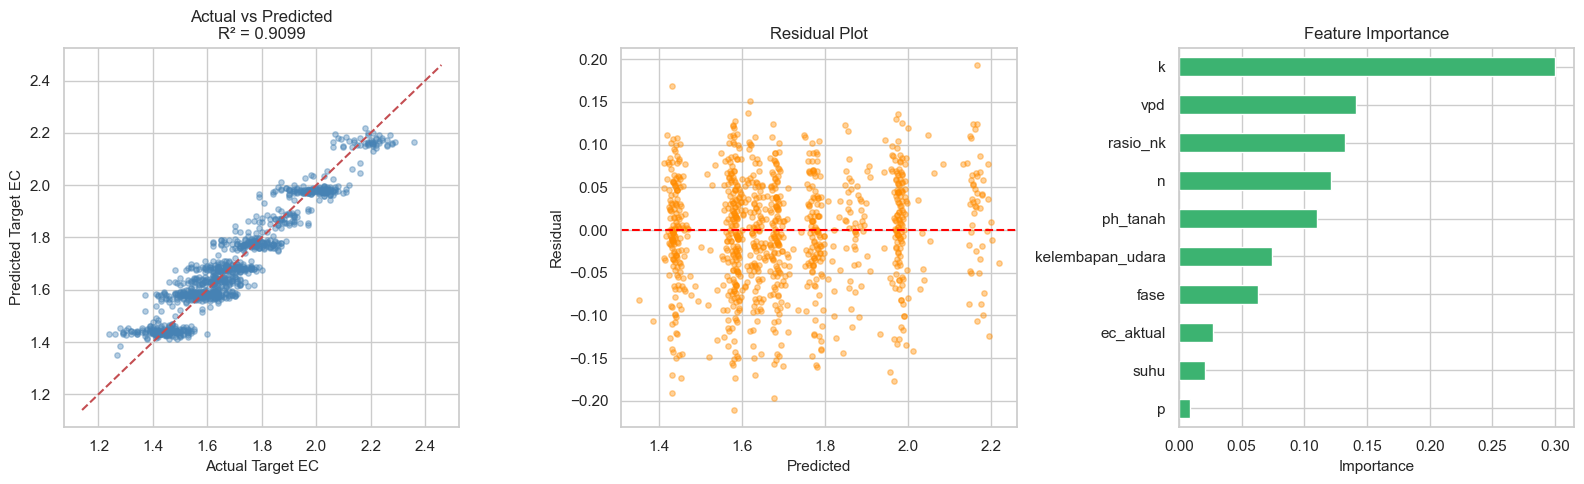

📊 Grafik disimpan → eval_model1_rf.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lim = [y_test.min()-0.1, y_test.max()+0.1]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Target EC', fontsize=11)
axes[0].set_ylabel('Predicted Target EC', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12)

# 2. Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Residual', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12)

# 3. Feature Importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Feature Importance', fontsize=12)
axes[2].set_xlabel('Importance', fontsize=11)

plt.tight_layout()
plt.savefig('eval_model1_rf.png', dpi=150)
plt.show()
print('📊 Grafik disimpan → eval_model1_rf.png')

## Cell 6 — Fungsi Hitung Saran Rasio A/B Mix

Asumsi konsentrat A & B: **5 ml per 10 L ≈ 1 mS/cm EC**  
Rasio A:B disesuaikan fase dan kondisi N:K tanaman.

In [6]:
def saran_ab_mix(target_ec, fase, rasio_nk, volume_air_liter=10):
    """
    Hitung volume A & B mix (ml) untuk volume_air_liter liter air.

    Referensi:
    - 1 mS/cm EC ≈ 5 ml A + 5 ml B per 10 L (patokan umum)
    - Fase vegetatif  : A sedikit lebih banyak (N dominan) → rasio A:B = 55:45
    - Fase generatif  : B sedikit lebih banyak (K/P dominan) → rasio A:B = 45:55
    - Jika N:K > 1.3  : naikkan porsi A
    - Jika N:K < 0.7  : naikkan porsi B
    """
    total_ml = target_ec * 5 * (volume_air_liter / 10)  # total konsentrat (ml)

    # Tentukan split awal berdasarkan fase
    if fase == 0:   # vegetatif
        split_a = 0.55
    else:           # generatif
        split_a = 0.45

    # Koreksi berdasarkan rasio N:K aktual
    if rasio_nk > 1.3:
        split_a = min(split_a + 0.05, 0.70)   # N terlalu tinggi → kurangi A
    elif rasio_nk < 0.7:
        split_a = max(split_a - 0.05, 0.30)   # K terlalu tinggi → kurangi B

    volume_a = round(total_ml * split_a, 1)
    volume_b = round(total_ml * (1 - split_a), 1)

    return {
        'target_ec'      : round(target_ec, 2),
        'volume_air_L'   : volume_air_liter,
        'volume_a_ml'    : volume_a,
        'volume_b_ml'    : volume_b,
        'rasio_a_b'      : f'{round(split_a*100)}:{round((1-split_a)*100)}',
        'catatan'        : 'Tuang A dulu, aduk, baru tuang B'
    }


def prediksi_full(n, p, k, ec_aktual, ph_tanah,
                  kelembapan_udara, suhu, fase,
                  volume_air_liter=10):
    """
    Endpoint utama: input sensor → prediksi target_ec + saran A/B mix.
    Ini yang dipanggil dari API cloud.
    """
    # Hitung VPD & rasio N:K
    es    = 0.6108 * np.exp((17.27*suhu)/(suhu+237.3))
    vpd   = float(es - es*(kelembapan_udara/100))
    rasio = n / k if k > 0 else 1.0

    x_input = np.array([[n, p, k, ec_aktual, ph_tanah,
                          kelembapan_udara, suhu, fase, vpd, rasio]])

    pred_ec = float(rf.predict(x_input)[0])
    pred_ec = round(np.clip(pred_ec, 0.8, 3.0), 2)

    saran = saran_ab_mix(pred_ec, fase, rasio, volume_air_liter)
    return saran


# ── Contoh penggunaan ──
hasil = prediksi_full(
    n=195, p=52, k=185,
    ec_aktual=1.55, ph_tanah=6.1,
    kelembapan_udara=72, suhu=27,
    fase=0,  # vegetatif
    volume_air_liter=10
)
print('=== Contoh Prediksi (Vegetatif) ===')
for k_, v in hasil.items():
    print(f'  {k_:<18}: {v}')

print()
hasil2 = prediksi_full(
    n=145, p=65, k=255,
    ec_aktual=1.90, ph_tanah=6.4,
    kelembapan_udara=65, suhu=30,
    fase=1,  # generatif
    volume_air_liter=10
)
print('=== Contoh Prediksi (Generatif) ===')
for k_, v in hasil2.items():
    print(f'  {k_:<18}: {v}')

=== Contoh Prediksi (Vegetatif) ===
  target_ec         : 1.57
  volume_air_L      : 10
  volume_a_ml       : 4.3
  volume_b_ml       : 3.5
  rasio_a_b         : 55:45
  catatan           : Tuang A dulu, aduk, baru tuang B

=== Contoh Prediksi (Generatif) ===
  target_ec         : 1.77
  volume_air_L      : 10
  volume_a_ml       : 3.5
  volume_b_ml       : 5.3
  rasio_a_b         : 40:60
  catatan           : Tuang A dulu, aduk, baru tuang B


## Cell 7 — Visualisasi Saran A/B Mix per Fase

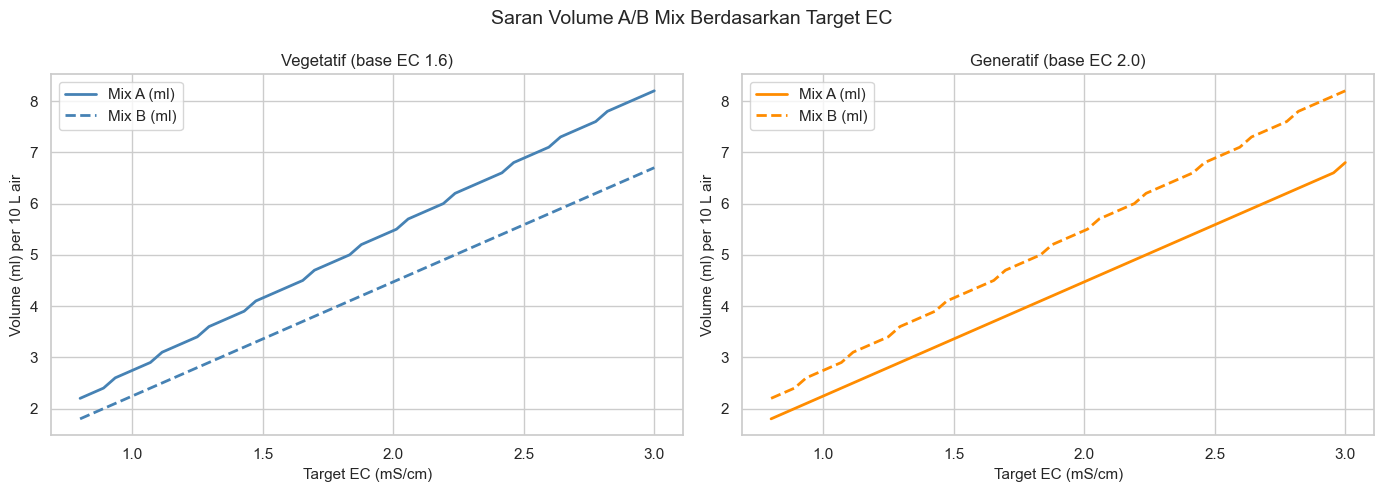

📊 Grafik disimpan → saran_ab_mix.png


In [7]:
ec_range = np.linspace(0.8, 3.0, 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fase_val, label, col in zip(
        axes, [0, 1],
        ['Vegetatif (base EC 1.6)', 'Generatif (base EC 2.0)'],
        ['steelblue', 'darkorange']):

    vol_a = [saran_ab_mix(ec, fase_val, 1.0)['volume_a_ml'] for ec in ec_range]
    vol_b = [saran_ab_mix(ec, fase_val, 1.0)['volume_b_ml'] for ec in ec_range]

    ax.plot(ec_range, vol_a, label='Mix A (ml)', color=col, linewidth=2)
    ax.plot(ec_range, vol_b, label='Mix B (ml)', color=col, linewidth=2, linestyle='--')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Target EC (mS/cm)', fontsize=11)
    ax.set_ylabel('Volume (ml) per 10 L air', fontsize=11)
    ax.legend()

plt.suptitle('Saran Volume A/B Mix Berdasarkan Target EC', fontsize=14)
plt.tight_layout()
plt.savefig('saran_ab_mix.png', dpi=150)
plt.show()
print('📊 Grafik disimpan → saran_ab_mix.png')

## Cell 8 — Simpan Model

In [8]:
# Simpan model RF
joblib.dump(rf, 'model1_target_ec.pkl')
print('✅ Model disimpan → model1_target_ec.pkl')

# Simpan metadata (untuk validasi di API)
metadata = {
    'features' : FEATURES,
    'target'   : TARGET,
    'mae'      : round(mae, 4),
    'rmse'     : round(rmse, 4),
    'r2'       : round(r2, 4),
    'ec_vegetatif_base': 1.6,
    'ec_generatif_base': 2.0,
    'n_samples': len(df),
    'ab_mix_note': '5 ml A + 5 ml B per 10 L ≈ 1 mS/cm EC'
}
with open('model1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Metadata disimpan → model1_metadata.json')

# Contoh cara load dan pakai di API
print()
print('── Cara load di Flask/FastAPI ──')
print("""
import joblib, json, numpy as np

rf    = joblib.load('model1_target_ec.pkl')
meta  = json.load(open('model1_metadata.json'))

# @app.post('/predict')
# def predict(data: SensorData):
#     result = prediksi_full(**data.dict())
#     return result
""")

✅ Model disimpan → model1_target_ec.pkl
✅ Metadata disimpan → model1_metadata.json

── Cara load di Flask/FastAPI ──

import joblib, json, numpy as np

rf    = joblib.load('model1_target_ec.pkl')
meta  = json.load(open('model1_metadata.json'))

# @app.post('/predict')
# def predict(data: SensorData):
#     result = prediksi_full(**data.dict())
#     return result

